In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [23]:
# Load data
df = pd.read_csv('combined_data.csv')

# FIX: Strip whitespace mn el-columns (Dah el-hy7el el-KeyError)
df.columns = df.columns.str.strip()

# Features Selection: stats el-shout el-awal + odds
features = ['HTHG', 'HTAG', 'HTR', 'B365H', 'B365D', 'B365A']
target = 'FTR'

# Drop missing values
df_clean = df[features + [target]].dropna()

print(f"Data Loaded. Total Matches: {len(df_clean)}")
df_clean.head()

Data Loaded. Total Matches: 3900


,HTHG,HTAG,HTR,B365H,B365D,B365A,FTR
0,1,0,H,1.48,4.00,8.00,D
1,1,0,H,2.35,3.40,3.00,D
2,0,1,A,2.00,3.20,4.10,H
3,1,1,D,2.80,3.25,2.63,D
4,0,1,A,1.85,3.30,4.50,D


In [24]:
# Encoding results (A, D, H -> 0, 1, 2)
le_htr = LabelEncoder()
df_clean['HTR'] = le_htr.fit_transform(df_clean['HTR'])

le_ftr = LabelEncoder()
df_clean['FTR'] = le_ftr.fit_transform(df_clean['FTR'])

# Split Data
X = df_clean[features]
y = df_clean[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Preprocessing Done: Data Split & Scaled")

Preprocessing Done: Data Split & Scaled


In [25]:
# multi_class='multinomial' 3ashan 3andena 3 labels
lr_model = LogisticRegression(multi_class='multinomial', max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

# Predictions
y_pred = lr_model.predict(X_test_scaled)

print("Model Training Completed")

Model Training Completed


/Users/ganna/Documents/machine-intelligence-project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression Accuracy: 63.33%

Classification Report:
              precision    recall  f1-score   support

           A       0.70      0.65      0.68       246
           D       0.40      0.29      0.33       184
           H       0.67      0.80      0.73       350

    accuracy                           0.63       780
   macro avg       0.59      0.58      0.58       780
weighted avg       0.62      0.63      0.62       780



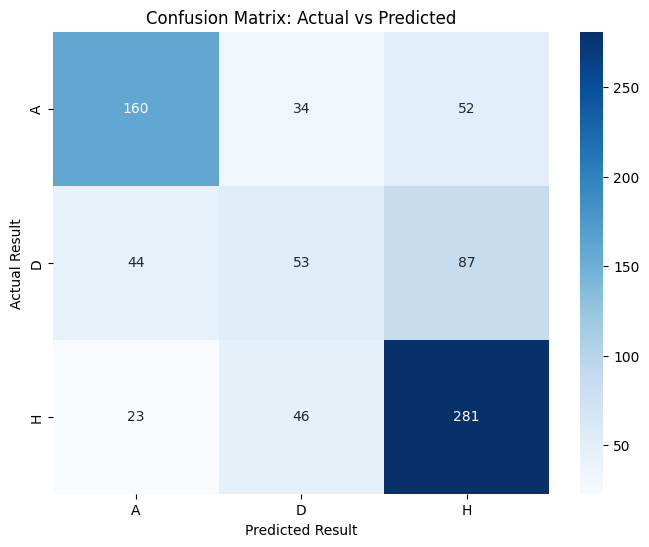

In [26]:
# Accuracy & Detailed Report
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le_ftr.classes_))

# Confusion Matrix Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', 
            xticklabels=le_ftr.classes_, yticklabels=le_ftr.classes_)
plt.title('Confusion Matrix: Actual vs Predicted')
plt.ylabel('Actual Result')
plt.xlabel('Predicted Result')
plt.show()

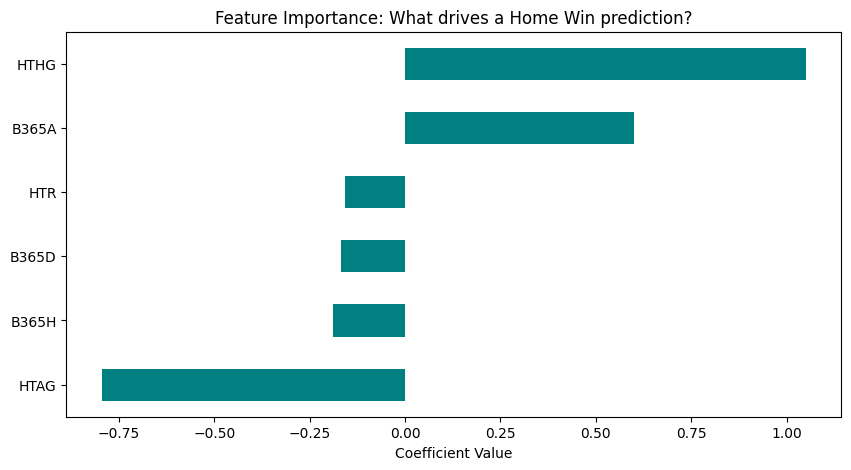

In [27]:
# Extract Coefficients for 'Home Win' (Class 2)
importance = lr_model.coef_[2] 
feat_importance = pd.Series(importance, index=features)

# Plotting
plt.figure(figsize=(10, 5))
feat_importance.sort_values().plot(kind='barh', color='teal')
plt.title('Feature Importance: What drives a Home Win prediction?')
plt.xlabel('Coefficient Value')
plt.show()